In [9]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [4]:
train_data = pd.read_csv("../data/train.csv")
train_data.head()

,paper_id,text,summary
0,0,## FROM SOVEREIGNTY TO EXTRATERRITORIAL CONSCI...,"In this article, Victor Fan argues that analys..."
1,1,## 1. Introduction\n\n\nAn Electronic Health R...,Problem definition: Physicians spend more than...
2,2,## Introduction\n\n\nTranslation plays an i...,Literary translation is one of the most challe...
3,3,## 1 Problem Setup\n\n\nRecent political scien...,There is a long-running debate on evaluating f...
4,4,## INTRODUCTION\n\n\nThis article investigat...,"Recently, ‘bimajyo’ (美魔女) came into focus in J..."


In [6]:
df = train_data.copy()

### Length distributions

In [11]:
df['text_words'] = df['text'].apply(lambda x: len(str(x).split()))
df['summary_words'] = df['summary'].str.split().apply(len)

print(df[['text_words', 'summary_words']].describe())

         text_words  summary_words
count   1000.000000    1000.000000
mean    6299.792000     184.204000
std     3276.873368      62.489129
min     1093.000000      12.000000
25%     4184.500000     147.000000
50%     5817.000000     182.000000
75%     7707.500000     215.000000
max    34087.000000     721.000000


array([[<Axes: title={'center': 'text_words'}>,
        <Axes: title={'center': 'summary_words'}>]], dtype=object)

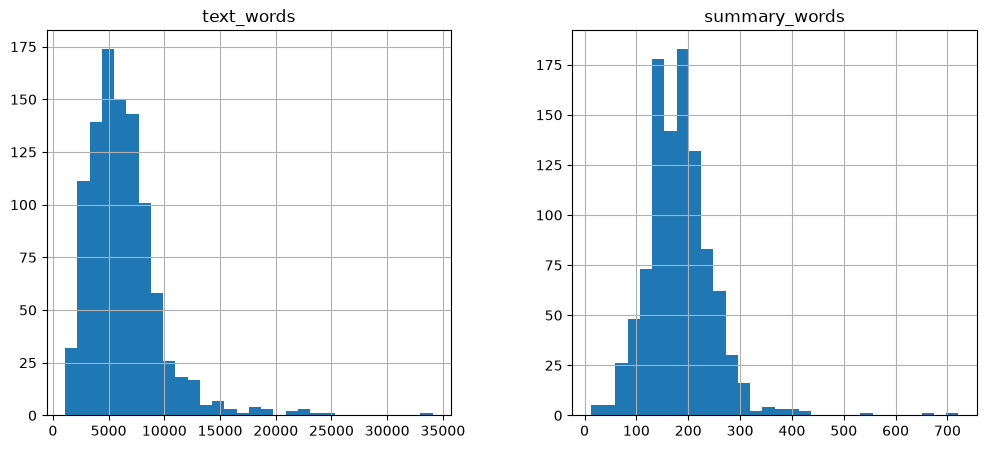

In [12]:
df[['text_words', 'summary_words']].hist(bins=30, figsize=(12, 5))

### Compression ratio

In [20]:
df['compression_ratio'] = df['summary_words'] / df['text_words']
print(df['compression_ratio'].describe())

count    1000.000000
mean        0.036253
std         0.023164
min         0.002002
25%         0.021735
50%         0.030331
75%         0.044830
max         0.301547
Name: compression_ratio, dtype: float64


<Axes: >

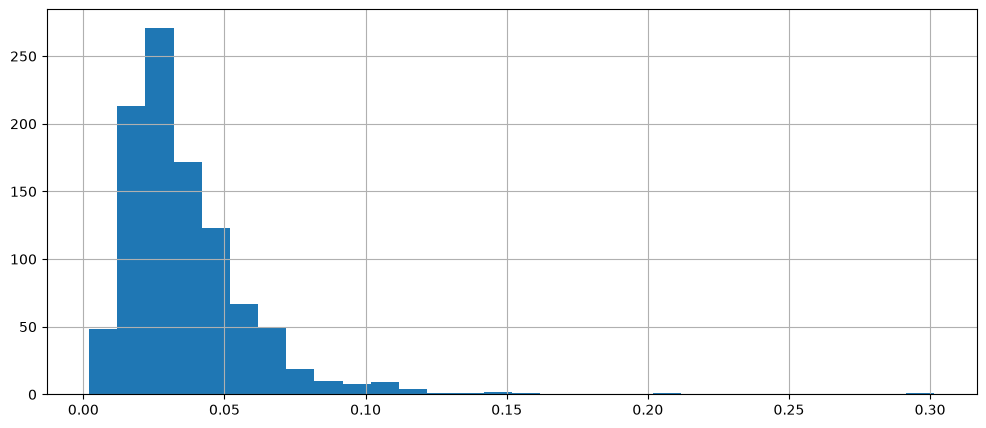

In [21]:
df['compression_ratio'].hist(bins=30, figsize=(12, 5))

### Outliers / duplicates

In [15]:
print('Text word count < 1000 (should be ~none, spec says >10k chars):')
print(df[df['text_words'] < 1000][['paper_id', 'text_words']])

Text word count < 1000 (should be ~none, spec says >10k chars):
Empty DataFrame
Columns: [paper_id, text_words]
Index: []


In [16]:
print("\nDuplicate paper_id:", df['paper_id'].duplicated().sum())
print("Duplicate text:", df['text'].duplicated().sum())


Duplicate paper_id: 0
Duplicate text: 0


### Spot-check random samples

In [17]:
import textwrap

for i in df.sample(3, random_state=42).index:
    print("="*80)
    print("PAPER:", df.loc[i, 'paper_id'])
    print("\n--- TEXT (first 800 chars) ---")
    print(textwrap.shorten(df.loc[i, 'text'], width=800))
    print("\n--- SUMMARY ---")
    print(df.loc[i, 'summary'])

PAPER: 521

--- TEXT (first 800 chars) ---
## 1. Introduction The police-involved deaths of George Floyd, Breonna Taylor, and other Black Americans led many to critically reappraise the role of police in society. These focusing events gave rise to widespread calls for reforms to diminish systemic racism and the role of law enforcement in American society by reducing local police budgets and reallocating those resources toward civilian agencies (Lum, Koper, &amp; Wu 2022). Amid increased attention to violent crime nationally (Brennan 2022; Goodman 2021), policymakers seek reforms to shift police resources toward crime control and prevention (Parker &amp; Hurst 2021). Empirical evidence supports both sides of this duality by demonstrating that expanded police presence (supported by increased spending) can reduce crime while [...]

--- SUMMARY ---
Reforms to deploy civilian responders to non-criminal emergency calls may reduce demands on police departments and reduce negative interactions

### Token Count vs model context window

Using a real tokenizer, not word count - word count underestimates tokens by about 30%.

In [19]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")
df['text_tokens'] = df['text'].apply(lambda x: len(enc.encode(x)))

for limit in [4096, 8_192, 16_384]:
    pct = (df['text_tokens'] > limit).mean() * 100
    print(f"% docs exceeding {limit} tokens: {pct:.1f}%")

% docs exceeding 4096 tokens: 90.0%
% docs exceeding 8192 tokens: 50.9%
% docs exceeding 16384 tokens: 5.3%


In [24]:
# Function to count tokens in a text
def count_tokens(text):
    enc = tiktoken.get_encoding("cl100k_base")
    return len(enc.encode(text))

In [28]:
# Chunking function to split text into smaller parts based on token count
def chunk_text(text, max_tokens = 2500):
    paragraphs = [p for p in text.split("\n") if p.strip()]
    chunks = []
    current_chunk = []
    current_tokens = 0

    for para in paragraphs:
        para_tokens = count_tokens(para)

        # Fallback: if a single paragraph exceeds max_tokens, we will hard split it
        if para_tokens > max_tokens:
            if current_chunk:
                chunks.append("\n".join(current_chunk))
                current_chunk = []
                current_tokens = 0

            # Split the paragraph into smaller parts
            words = para.split()
            sub_chunk = []
            sub_tokens = 0
            for w in words:
                w_tokens = count_tokens(w)

                # If adding this word exceeds the max_tokens, finalize the current sub_chunk
                if sub_tokens + w_tokens > max_tokens:
                    chunks.append(" ".join(sub_chunk))
                    sub_chunk = []
                    sub_tokens = 0

                sub_chunk.append(w)
                sub_tokens += w_tokens

            if sub_chunk:
                chunks.append(" ".join(sub_chunk))
            continue

        #Normal Case: does this paragraph fit in the current chunk?
        if current_tokens + para_tokens > max_tokens:
            # If not, finalize the current chunk and start a new one
            chunks.append("\n".join(current_chunk))
            current_chunk = [para]
            current_tokens = para_tokens
        else:
            # If it fits, add it to the current chunk
            current_chunk.append(para)
            current_tokens += para_tokens

    if current_chunk:
        chunks.append("\n".join(current_chunk))

    return chunks


In [32]:
chunks = chunk_text(df.loc[0, 'text'], max_tokens=2500)
print([count_tokens(c) for c in chunks])

[2385, 2307, 2239, 802]


In [37]:
len(chunks[0])

10027